## Example for pairing IAGOS data with UFS-AQM

This example demonstrates how to use MELODIES MONET to pair aircraft observations from IAGOS (https://www.iagos.org/) to model output from the UFS-AQM for a single flight. Loop pairing following the AEROMMA examples can be used.

This example uses the flight timeseries IAGOS data rather than the profile data, though it will work with either format. There may be more than one IAGOS flight collecting data at a time and so right now it is recommended to set up the pairing to only process one flight at a time. Resulting from this potential time alignment, use of the plotting and statistics auto-generation tools for multiple flights is limited.

### First, import the driver and initiate the analysis class

In [1]:
from melodies_monet import driver

an = driver.analysis()

### Second, we read in a control file

This control file must include renaming of some variables for both models and IAGOS observations. The model section should rename "press_pa_mid" to "pressure_model". The observation section should rename lat, lon, UTC_time, air_press_AC, and baro_alt_AC to the more standard names of "latitude", "longitude", "time", "pressure_obs", and "altitude".

In [2]:
an.control = '/scratch3/BMC/rcm2/mbruckner/melodies/MELODIES-MONET/examples/yaml/control_iagos_AEROMMA_UFSAQM.yaml'
an.read_control()

### Load the model and observation data

In [3]:
an.open_models()

ufs
/scratch3/BMC/rcm2/rhs/monet_example/AEROMMA/UFS-AQM/cmaq54_OriRave1/aqm.202306*/12/aqm.t12z.dyn.*.nc
**** Reading UFS-AQM or UFS-Chem model output...


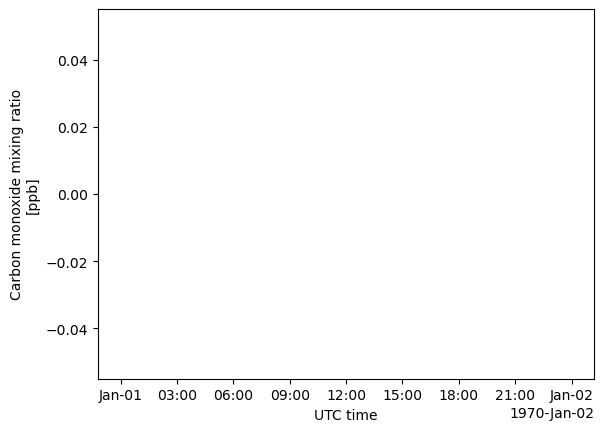

In [4]:
an.open_obs()
an.obs['iagos'].obj['CO_P1'].plot()

### Pair the observations and model data

In [5]:
an.pair_data()

1, in pair data


After pairing:       longitude  latitude  altitude                time  \
0      13.2318   -8.8603      49.4 2023-06-28 21:03:23   
1      13.2301   -8.8618      48.8 2023-06-28 21:03:27   
2      13.2286   -8.8632      48.2 2023-06-28 21:03:31   
3      13.2267   -8.8649      45.1 2023-06-28 21:03:35   
4      13.2248   -8.8668      34.7 2023-06-28 21:03:39   
..         ...       ...       ...                 ...   
493    11.8972   -6.0143   10959.9 2023-06-28 21:36:15   
494    11.8954   -6.0061   10960.9 2023-06-28 21:36:19   
495    11.8936   -5.9975   10961.5 2023-06-28 21:36:23   
496    11.8917   -5.9889   10960.6 2023-06-28 21:36:27   
497    11.8898   -5.9807   10961.8 2023-06-28 21:36:31   

     baro_alt_AC_validity_flag  radio_alt_AC  radio_alt_AC_validity_flag  \
0                          0.0           0.2                         0.0   
1                          0.0           0.2                         0.0   
2                          0.0           0.2               

### Generate plots

In [6]:
an.plotting()